# Visualise Forced Henry Dataset — IC + inflow → trajectory

Datasets from `generate_henry_forced_scenarios.sh` (package `henry_forced/`): classic Henry boundary conditions
(constant freshwater inflow $Q$ on the left, sea-level GHB with $C = 35$ on the right, no-flow top/bottom, no storage).

Each **scenario** is one `(beta_c, diffc)` pair stored as `scenario_NNN/scenario.npz`. By default every scenario draws its **own run set**
(initial field $C_0$ and inflow $Q$, seed `[SEED, scenario_index]`). Datasets made with `SHARED_RUNS=1` (and those generated before that option
existed) reuse **one run set** in every scenario, so run `i` has the same $C_0$ and $Q$ everywhere. The notebook reads which one from the manifest.

```
input_tensor   : (n_runs, 7, T-1, nlay, ncol)  — channels: C0 (repeated), inflow (Q broadcast; older datasets: Q in column 0 only), beta_c, diffc,
                                                 coord_t, coord_z, coord_x (older datasets: 4 channels, no coordinates)
output_tensor  : (n_runs, 2, T-1, nlay, ncol)  — channels: conc, head  over t_1 .. t_{T-1}
inflow         : (n_runs,)                     — total inflow Q [m³/d] per run
run_params     : (n_runs,)                     — per-run JSON (IC parameters, field seed, Q)
```

The notebook rebuilds the full trajectory $t_0 \dots t_{T-1}$ ($t_0$ = the IC; head is not stored at $t_0$, so that frame is blank).

**Wedge diagnostics** used below:
- **Toe position** $x_{toe}$: where the 50 % isochlor ($C = 17.5$) crosses the aquifer base (interpolated between cells). Smaller = more intrusion.
- **Henry numbers** (Henry 1964; Simpson & Clement 2004): $a = Q / (K\,\varepsilon\,L_z)$ with $\varepsilon = \beta_C c_{sea}$, and $b = D / Q$. Classic Henry: $a \approx 0.26$, $b = 0.1$.

Sections:
1. **Metadata**: dataset and scenario summary
2. **Input channels** of one run
3. **Spatial snapshots** of one run, with isochlors
4. **Time strip** of one run
5. **Same run index across all scenarios** (identical IC and Q only for shared run sets)
   - **4b** time strip of that run in four corner scenarios (paper figure)
6. **Effect of inflow** within a scenario
7. **Approach to steady state**: toe position and distance to the final state over time
8. **Dataset-wide**: final toe position against $Q$ and the Henry number $a$
9. **Target statistics** across runs

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ── Configure path ──────────────────────────────────────────────────────────
DATA_DIR     = Path('~/Projects/groundwater/data/henry_forced_data/').expanduser()
DATASET_NAME = 'grid_scenarios_forced_random_skip2_20x40'
SCENARIO     = 'scenario_005'

DATASET_DIR = DATA_DIR / DATASET_NAME
manifest = json.load(open(DATASET_DIR / 'manifest.json'))

pde   = manifest['pde']
grid  = manifest['grid']
HK    = pde['hk']
C_SEA = pde['c_sea']

manifest_df = pd.DataFrame(manifest['scenarios'])
manifest_df['epsilon'] = manifest_df['beta_c'] * C_SEA          # (ρ_sea − ρ_0) / ρ_0
q_lo, q_hi = manifest['inflow_range']
manifest_df['a_range'] = [
    f'{q_lo / (HK * e * grid["lz"]):.2f} – {q_hi / (HK * e * grid["lz"]):.2f}'
    for e in manifest_df['epsilon']
]
manifest_df['b_range'] = [f'{d / q_hi:.3f} – {d / q_lo:.3f}' for d in manifest_df['diffc']]

print(f'Dataset     : {DATASET_NAME}')
print(f'Grid        : nlay={grid["nlay"]}  ncol={grid["ncol"]}  Lx={grid["lx"]} m  Lz={grid["lz"]} m')
print(f'Time        : total={manifest["time"]["total_time"]} d  nstp={manifest["time"]["nstp"]}  '
      f'skip={manifest["skip"]}  dt_eff={manifest["dt_eff"]} d  T_out={manifest["T_out"]}')
print(f'Physics     : K={HK} m/d  por={pde["por"]}  rho0={pde["rho0"]}  c_sea={C_SEA}')
# Older datasets lack these keys: they used one shared run set and Q in the left column only
SHARED_RUNS     = manifest.get('shared_runs', True)
INFLOW_ENCODING = manifest.get('inflow_encoding', 'left_column')

print(f'Inflow Q    : U[{q_lo}, {q_hi}] m³/d  (input encoding: {INFLOW_ENCODING})')
print(f'Run sets    : {"one set shared by all scenarios" if SHARED_RUNS else "independent per scenario"}')
print(f'IC          : {manifest["init_method"]}  {manifest["init_field_args"]}')
print(f'Runs        : {manifest["n_ok_runs"]} ok / {manifest["n_total_runs"]} total  '
      f'({manifest["n_failed_runs"]} failed)')
manifest_df[['scenario', 'beta_c', 'diffc', 'epsilon', 'a_range', 'b_range', 'n_ok_runs']]

Dataset     : grid_scenarios_forced_random_skip2_20x40
Grid        : nlay=20  ncol=40  Lx=2.0 m  Lz=1.0 m
Time        : total=0.25 d  nstp=50  skip=2  dt_eff=0.01 d  T_out=25
Physics     : K=864.0 m/d  por=0.35  rho0=1000.0  c_sea=35.0
Inflow Q    : U[2.0, 6.0] m³/d  (input encoding: broadcast)
Run sets    : independent per scenario
IC          : random  {'random_field_type': ['grf'], 'random_field_smoothness': [0.8], 'random_field_len_scale': [0.1, 0.3, 0.5, 0.7, 0.9], 'random_field_var': [0.1, 0.3, 0.5, 0.7], 'random_field_count': 20, 'random_field_taper': False, 'random_field_period': 2.0}
Runs        : 4800 ok / 4800 total  (0 failed)


,scenario,beta_c,diffc,epsilon,a_range,b_range,n_ok_runs
0,scenario_001,0.00035,0.05000,0.01225,0.19 – 0.57,0.008 – 0.025,400
1,scenario_002,0.00035,0.10000,0.01225,0.19 – 0.57,0.017 – 0.050,400
2,scenario_003,0.00035,0.30000,0.01225,0.19 – 0.57,0.050 – 0.150,400
3,scenario_004,0.00035,0.57024,0.01225,0.19 – 0.57,0.095 – 0.285,400
4,scenario_005,0.00070,0.05000,0.02450,0.09 – 0.28,0.008 – 0.025,400
5,scenario_006,0.00070,0.10000,0.02450,0.09 – 0.28,0.017 – 0.050,400
6,scenario_007,0.00070,0.30000,0.02450,0.09 – 0.28,0.050 – 0.150,400
7,scenario_008,0.00070,0.57024,0.02450,0.09 – 0.28,0.095 – 0.285,400
8,scenario_009,0.00140,0.05000,0.04900,0.05 – 0.14,0.008 – 0.025,400
9,scenario_010,0.00140,0.10000,0.04900,0.05 – 0.14,0.017 – 0.050,400


In [2]:
# ── Load one scenario ────────────────────────────────────────────────────────
data = np.load(DATASET_DIR / SCENARIO / 'scenario.npz')

inp = data['input_tensor']    # (n_runs, 4, T_out, nlay, ncol)
out = data['output_tensor']   # (n_runs, 2, T_out, nlay, ncol)
n_runs, C_in, T_out, nlay, ncol = inp.shape

beta_c = float(data['beta_c'])
diffc  = float(data['diffc'])
lx, lz = float(data['lx']), float(data['lz'])
dt_eff = float(data['dt_eff'])

in_ch  = [str(s) for s in data['input_channel_names']]
out_ch = [str(s) for s in data['output_channel_names']]
IN_IDX  = {name: i for i, name in enumerate(in_ch)}
OUT_IDX = {name: i for i, name in enumerate(out_ch)}
CONC_IN, INFLOW_IN = IN_IDX['concentration_0'], IN_IDX['inflow']
CONC_OUT, HEAD_OUT = OUT_IDX['concentration'], OUT_IDX['head']

times_full = np.concatenate([[0.0], data['times_out']])   # t_0 .. t_{T-1}
T_total = len(times_full)

# Per-run metadata
runs_df = pd.DataFrame([json.loads(str(s)) for s in data['run_params']])
runs_df['henry_a'] = runs_df['inflow'] / (HK * beta_c * C_SEA * lz)
runs_df['henry_b'] = diffc / runs_df['inflow']

print(f'Scenario   : {SCENARIO}  beta_c={beta_c}  diffc={diffc}')
print(f'Runs       : {n_runs}')
print(f'Input      : {inp.shape}   channels: {in_ch}')
print(f'Output     : {out.shape}   channels: {out_ch}')
print(f'Trajectory : T={T_total} frames, t = {times_full[0]:.2f} .. {times_full[-1]:.2f} d  (dt_eff={dt_eff} d)')
runs_df[['inflow', 'henry_a', 'henry_b', 'random_field_len_scale', 'random_field_var', 'sample_idx']].describe().T

Scenario   : scenario_005  beta_c=0.0007  diffc=0.05
Runs       : 400
Input      : (400, 7, 25, 20, 40)   channels: ['concentration_0', 'inflow', 'beta_c', 'diffc', 'coord_t', 'coord_z', 'coord_x']
Output     : (400, 2, 25, 20, 40)   channels: ['concentration', 'head']
Trajectory : T=26 frames, t = 0.00 .. 0.25 d  (dt_eff=0.01 d)


,count,mean,std,min,25%,50%,75%,max
inflow,400.0,3.891307,1.140010,2.014277,2.964690,3.789922,4.901035,5.996175
henry_a,400.0,0.183830,0.053855,0.095157,0.140055,0.179040,0.231530,0.283266
henry_b,400.0,0.014096,0.004443,0.008339,0.010202,0.013193,0.016865,0.024823
random_field_len_scale,400.0,0.500000,0.283197,0.100000,0.300000,0.500000,0.700000,0.900000
random_field_var,400.0,0.400000,0.223887,0.100000,0.250000,0.400000,0.550000,0.700000
sample_idx,400.0,9.500000,5.773503,0.000000,4.750000,9.500000,14.250000,19.000000


In [3]:
# ── Helpers ──────────────────────────────────────────────────────────────────
dx, dz = lx / ncol, lz / nlay
X_C = (np.arange(ncol) + 0.5) * dx            # cell-centre x
Z_C = lz - (np.arange(nlay) + 0.5) * dz       # cell-centre z (row 0 = top)
EXTENT = [0, lx, 0, lz]
ISOCHLORS = [0.1 * C_SEA, 0.5 * C_SEA, 0.9 * C_SEA]

CHANNEL_LABELS = {
    'concentration_0': r'$C_0$ [kg/m³]',
    'inflow':          r'$Q$ [m³/d]',
    'beta_c':          r'$\beta_C$ [m³/kg]',
    'diffc':           r'$D$ [m²/d]',
    'coord_t':         r'$t$ [d] (coordinate)',
    'coord_z':         r'$z$ [m] (coordinate)',
    'coord_x':         r'$x$ [m] (coordinate)',
    'concentration':   r'$C$ [kg/m³]',
    'head':            r'$h$ [m]',
}
CMAPS = {
    'concentration_0': 'RdYlBu_r',
    'inflow':          'Blues',
    'beta_c':          'Greens',
    'diffc':           'Purples',
    'coord_t':         'Greys',
    'coord_z':         'Greys',
    'coord_x':         'Greys',
    'concentration':   'RdYlBu_r',
    'head':            'coolwarm',
}


def _imshow(ax, field, title='', cmap='RdYlBu_r', vmin=None, vmax=None,
            cbar=True, isochlors=False, labels=True):
    # Plot a (nlay, ncol) field with row 0 at the top (z = Lz). NaN = blank.
    im = ax.imshow(field, origin='upper', aspect='equal', extent=EXTENT,
                   cmap=cmap, vmin=vmin, vmax=vmax, interpolation='nearest')
    if isochlors and np.isfinite(field).all():
        cs = ax.contour(X_C, Z_C[::-1], field[::-1], levels=ISOCHLORS,
                        colors='k', linewidths=0.6, linestyles=['--', '-', ':'])
    ax.set_title(title, fontsize=9)
    if labels:
        ax.set_xlabel('x [m]', fontsize=8)
        ax.set_ylabel('z [m]', fontsize=8)
    else:
        ax.set_xticks([]); ax.set_yticks([])
    ax.tick_params(labelsize=7)
    if cbar:
        cb = plt.colorbar(im, ax=ax, shrink=0.8, pad=0.02)
        cb.ax.tick_params(labelsize=7)
    return im


def full_timeseries(run_idx, inp_arr=None, out_arr=None):
    # Full trajectory t_0 .. t_{T-1}: conc, head (T, nlay, ncol); head at t_0 is NaN.
    inp_arr = inp if inp_arr is None else inp_arr
    out_arr = out if out_arr is None else out_arr
    c0 = inp_arr[run_idx, CONC_IN, :1]
    conc = np.concatenate([c0, out_arr[run_idx, CONC_OUT]], axis=0)
    head = np.concatenate([np.full_like(c0, np.nan), out_arr[run_idx, HEAD_OUT]], axis=0)
    return conc, head


def toe_position(conc, level=0.5):
    # x where the `level` isochlor crosses the base, for conc of shape (..., nlay, ncol).
    # Linear interpolation from the left (fresh) side; Lx if the base is fresh everywhere.
    thr  = level * C_SEA
    base = np.asarray(conc)[..., -1, :]
    lead = base.shape[:-1]
    base = base.reshape(-1, ncol)
    toe  = np.full(base.shape[0], lx)
    for i, row in enumerate(base):
        j = int(np.argmax(row >= thr))
        if row[j] < thr:
            continue                      # never reaches the threshold
        if j == 0:
            toe[i] = 0.0
        else:
            w = (thr - row[j - 1]) / (row[j] - row[j - 1])
            toe[i] = X_C[j - 1] + w * dx
    return toe.reshape(lead)


def run_title(run_idx):
    r = runs_df.iloc[run_idx]
    return (f'run {run_idx}: Q={r.inflow:.2f} m³/d  (a={r.henry_a:.2f}, b={r.henry_b:.3f})  '
            f'IC len={r.random_field_len_scale} var={r.random_field_var}')

## 1 · Input channels of one run

All four input channels at the first time index (they are constant in time). Newer datasets also carry the $(t, z, x)$ coordinate channels, which are the same for every run.

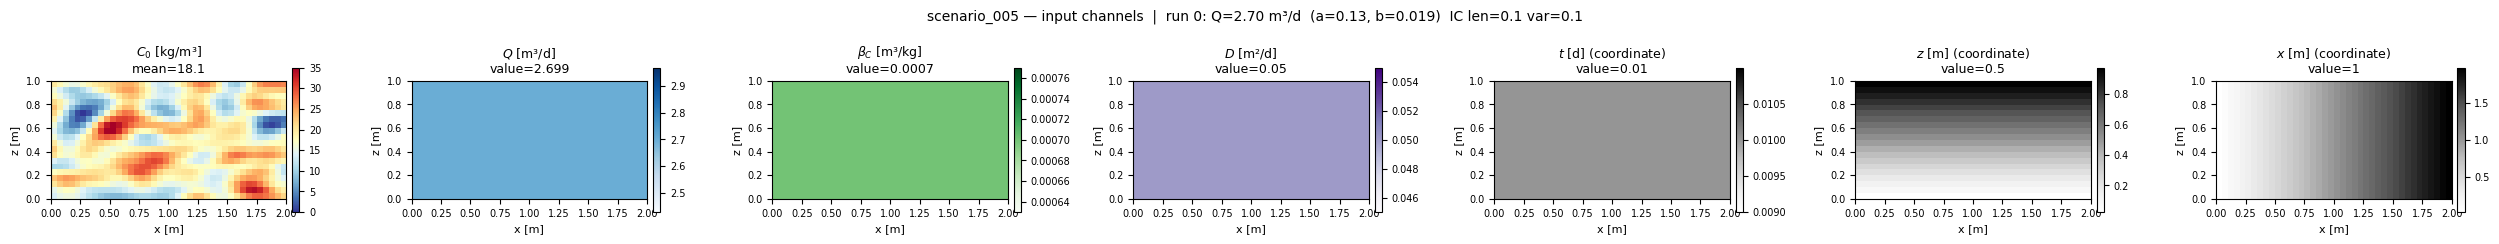

In [4]:
RUN_IDX = 0

fig, axes = plt.subplots(1, C_in, figsize=(3.6 * C_in, 2.4))
fig.suptitle(f'{SCENARIO} — input channels  |  {run_title(RUN_IDX)}', fontsize=10)

for ch, ax in enumerate(axes):
    name  = in_ch[ch]
    field = inp[RUN_IDX, ch, 0]
    nonzero = field[field != 0]
    stat = f'value={nonzero.mean():.4g}' if name != 'concentration_0' else f'mean={field.mean():.3g}'
    _imshow(ax, field, f'{CHANNEL_LABELS.get(name, name)}\n{stat}', CMAPS.get(name, 'viridis'))

plt.tight_layout()
plt.show()

## 2 · Spatial snapshots of one run

Concentration (with the 10 / 50 / 90 % isochlors) and head at selected times. Frame $t_0$ is the input (the IC); the rest are targets.

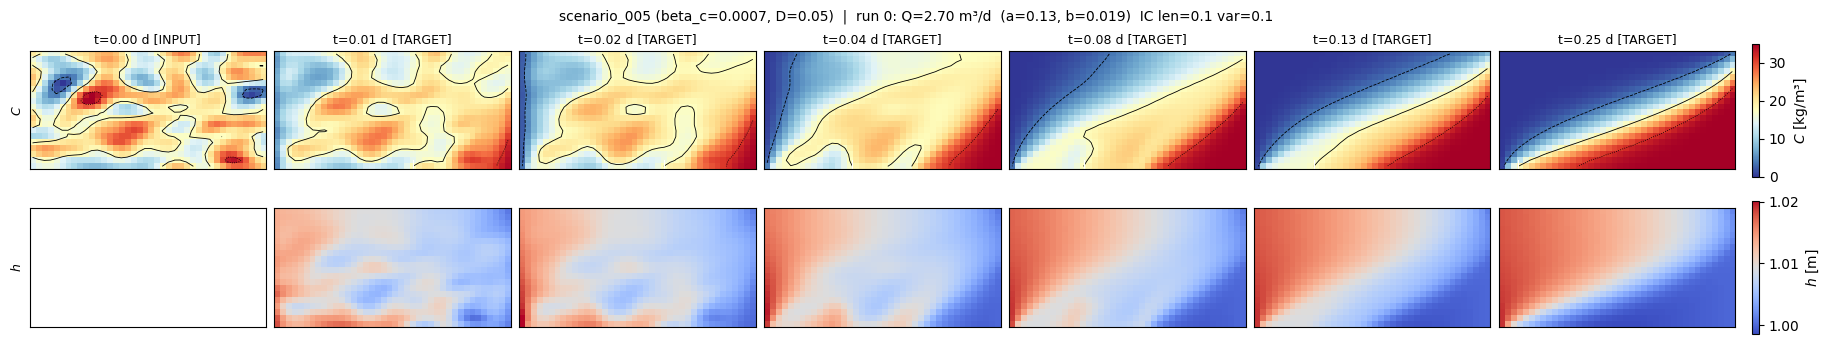

In [5]:
RUN_IDX = 0
SNAPSHOT_IDX = [0, 1, 2, 4, 8, T_total // 2, T_total - 1]

conc_full, head_full = full_timeseries(RUN_IDX)
snap = [i for i in dict.fromkeys(SNAPSHOT_IDX) if 0 <= i < T_total]

fig, axes = plt.subplots(2, len(snap), figsize=(2.6 * len(snap), 3.4), constrained_layout=True)
fig.suptitle(f'{SCENARIO} (beta_c={beta_c}, D={diffc})  |  {run_title(RUN_IDX)}', fontsize=10)

h_vmin, h_vmax = np.nanmin(head_full), np.nanmax(head_full)
for col, tidx in enumerate(snap):
    phase = 'INPUT' if tidx == 0 else 'TARGET'
    title = f't={times_full[tidx]:.2f} d [{phase}]'
    im_c = _imshow(axes[0, col], conc_full[tidx], title, 'RdYlBu_r', 0, C_SEA,
                   cbar=False, isochlors=True, labels=False)
    im_h = _imshow(axes[1, col], head_full[tidx], '', 'coolwarm', h_vmin, h_vmax,
                   cbar=False, labels=False)
    if tidx > 0:
        axes[0, col].axvline(toe_position(conc_full[tidx]), color='w', lw=0.8, ymax=0.08)

axes[0, 0].set_ylabel(r'$C$', fontsize=9)
axes[1, 0].set_ylabel(r'$h$', fontsize=9)
fig.colorbar(im_c, ax=axes[0], shrink=0.9, pad=0.01, label=r'$C$ [kg/m³]')
fig.colorbar(im_h, ax=axes[1], shrink=0.9, pad=0.01, label=r'$h$ [m]')
plt.show()

## 3 · Time strip of one run

Every `FRAME_STRIDE`-th frame side by side, giving a condensed view of the whole trajectory. The dashed line separates the input frame ($t_0$) from the targets.

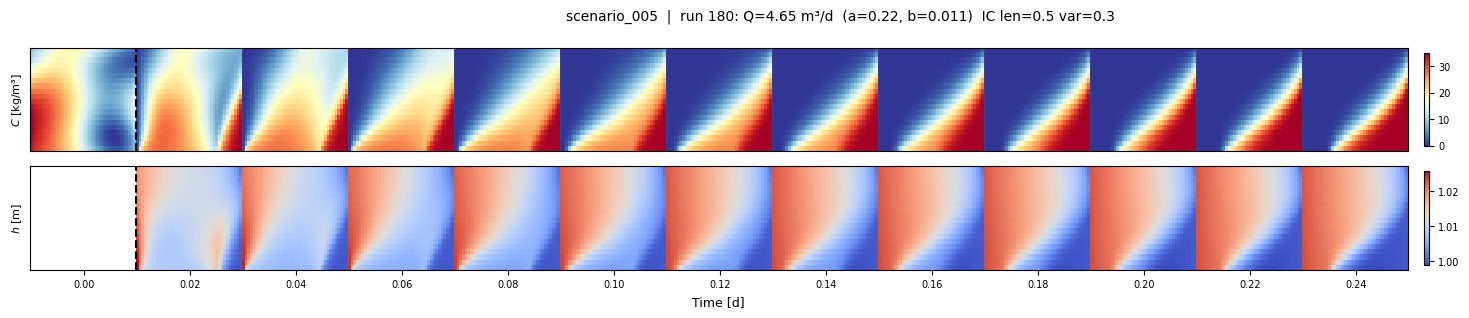

In [6]:
RUN_IDX      = 180
FRAME_STRIDE = 2

conc_full, head_full = full_timeseries(RUN_IDX)
frame_idx = np.arange(0, T_total, FRAME_STRIDE)
n_fr = len(frame_idx)

conc_strip = np.concatenate([conc_full[i] for i in frame_idx], axis=1)
head_strip = np.concatenate([head_full[i] for i in frame_idx], axis=1)

fig, axes = plt.subplots(2, 1, figsize=(min(1.3 * n_fr, 22), 3.2))
fig.suptitle(f'{SCENARIO}  |  {run_title(RUN_IDX)}', fontsize=10)

for ax, strip, label, cmap, lims in zip(
    axes, [conc_strip, head_strip], [r'$C$ [kg/m³]', r'$h$ [m]'], ['RdYlBu_r', 'coolwarm'],
    [(0, C_SEA), (np.nanmin(head_strip), np.nanmax(head_strip))],
):
    im = ax.imshow(strip, origin='upper', aspect='auto', cmap=cmap, vmin=lims[0], vmax=lims[1],
                   interpolation='nearest')
    ax.set_ylabel(label, fontsize=8)
    ax.set_yticks([])
    cb = plt.colorbar(im, ax=ax, shrink=0.9, pad=0.01)
    cb.ax.tick_params(labelsize=7)
    ax.axvline(ncol - 0.5, color='k', lw=1.5, ls='--')
    for k in range(2, n_fr):
        ax.axvline(k * ncol - 0.5, color='gray', lw=0.5, ls=':', alpha=0.5)
    ax.set_xticks([])

axes[-1].set_xticks([k * ncol + ncol / 2 for k in range(n_fr)])
axes[-1].set_xticklabels([f'{times_full[i]:.2f}' for i in frame_idx], fontsize=7)
axes[-1].set_xlabel('Time [d]', fontsize=9)
plt.tight_layout()
plt.show()

## 4 · Same run index across all scenarios

Run `RUN_IDX` from every scenario: $\beta_C$ in rows, $D$ in columns. With a **shared** run set this run has the same $C_0$ and $Q$ everywhere, so the grid
isolates the effect of $\beta_C$ and $D$. With **independent** run sets (the default) every panel is a different $C_0$ and $Q$; compare panels through $a$ and the toe.
Each panel shows concentration at time index `T_IDX` with the isochlors and the toe position.

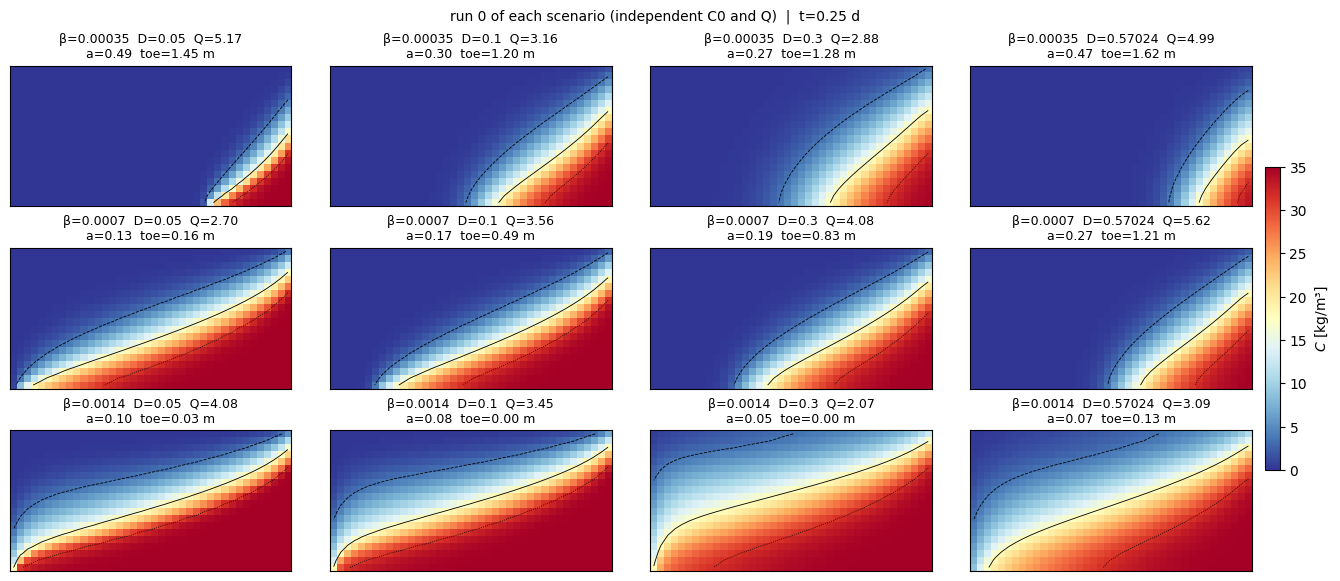

In [7]:
RUN_IDX = 0
T_IDX   = -1     # -1 = last frame; try 1 or 3 to see the early transient

betas  = np.sort(manifest_df['beta_c'].unique())
diffcs = np.sort(manifest_df['diffc'].unique())

fig, axes = plt.subplots(len(betas), len(diffcs), figsize=(3.4 * len(diffcs), 1.9 * len(betas)),
                         squeeze=False, constrained_layout=True)
t_idx = T_IDX % T_total
head = run_title(RUN_IDX) if SHARED_RUNS else f'run {RUN_IDX} of each scenario (independent C0 and Q)'
fig.suptitle(f'{head}  |  t={times_full[t_idx]:.2f} d', fontsize=10)

for r, b in enumerate(betas):
    for c, dc in enumerate(diffcs):
        row = manifest_df[(manifest_df['beta_c'] == b) & (manifest_df['diffc'] == dc)].iloc[0]
        d = np.load(DATASET_DIR / row['scenario'] / 'scenario.npz')
        conc_s, _ = full_timeseries(RUN_IDX, d['input_tensor'], d['output_tensor'])
        a = float(d['inflow'][RUN_IDX]) / (HK * b * C_SEA * lz)
        field = conc_s[t_idx]
        im = _imshow(axes[r, c], field,
                     f'β={b:g}  D={dc:g}  Q={float(d["inflow"][RUN_IDX]):.2f}\na={a:.2f}  toe={toe_position(field):.2f} m',
                     'RdYlBu_r', 0, C_SEA, cbar=False, isochlors=t_idx > 0, labels=False)

fig.colorbar(im, ax=axes, shrink=0.6, pad=0.01, label=r'$C$ [kg/m³]')
plt.show()

## 4b · Time strip across scenarios

The same run index in four scenarios: {min, max} `beta_c` × {min, max} `diffc`, selected from the dataset manifest.
Each row is labelled with its $\beta_C$, $D$, inflow $Q$ and Henry numbers $a = Q/(K\varepsilon L_z)$, $b = D/Q$ (the governing numbers here, rather than Ra).
Concentration uses one colour scale across all rows. Head magnitude scales with $\beta_C$ and $Q$, so each head row has its own colour scale.
Set `FRAME_STRIDE = 1` to show every frame or `2` for every other frame. Figure titles are printed above the plots rather than drawn on them, so the figures can go straight into a paper.

With independent run sets (the default) each row has its own $C_0$ and $Q$; with a shared run set the rows have identical $C_0$ and $Q$.

concentration — run 0 across scenarios (13 frames, every 2 step(s))
  IC: type=grf, len_scale=0.1, var=0.1 (independent C0 and Q per row)
  First 1 frame(s) = INPUT, separated by a wider gap from the TARGET



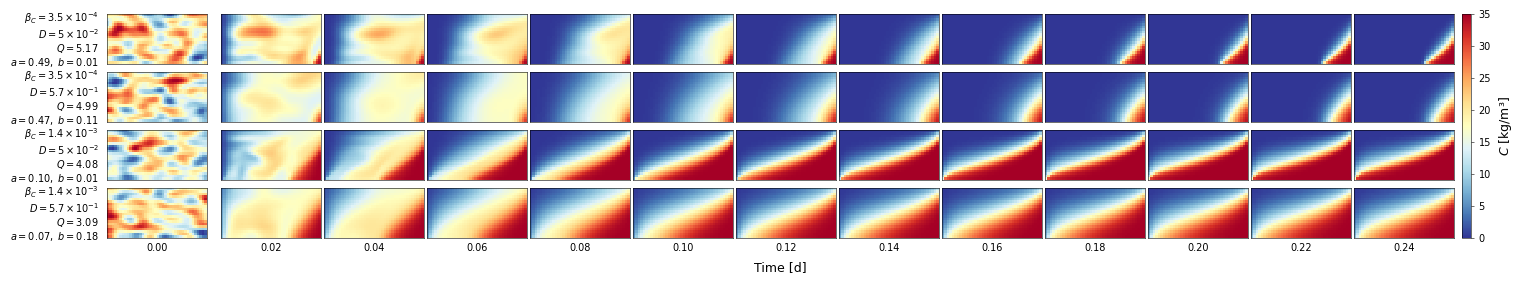

head — run 0 across scenarios (12 frames, every 2 step(s))
  IC: type=grf, len_scale=0.1, var=0.1 (independent C0 and Q per row)



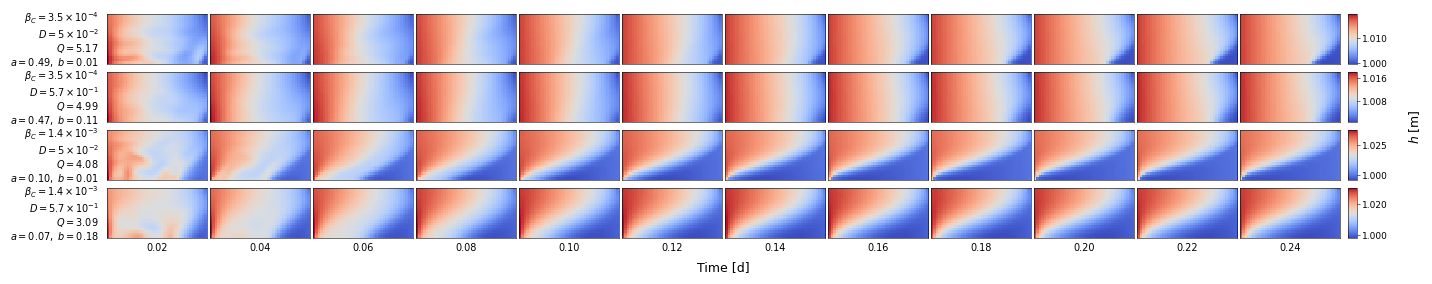

In [8]:
RUN_IDX      = 0
FRAME_STRIDE = 2   # 1 = every frame, 2 = every other frame (half)

# ── Select scenarios: {min, max} beta_c × {min, max} diffc ──────────────────
betas  = np.sort(manifest_df['beta_c'].unique())
diffcs = np.sort(manifest_df['diffc'].unique())
sel_betas  = list(dict.fromkeys([betas[0], betas[-1]]))
sel_diffcs = list(dict.fromkeys([diffcs[0], diffcs[-1]]))

sel = [
    manifest_df[(manifest_df['beta_c'] == b) & (manifest_df['diffc'] == dc)].iloc[0]
    for b in sel_betas for dc in sel_diffcs
]

# ── Frames per field: head is not stored at t_0, so its strip starts at t_1 ──
frame_idx = np.arange(0, T_total, FRAME_STRIDE)
frames = {
    'concentration': frame_idx,
    'head': frame_idx[frame_idx >= 1],
}

# ── Load the same run index from each scenario ──────────────────────────────
series = {'concentration': [], 'head': []}   # per scenario: (n_frames, nlay, ncol)
row_q  = []                                  # inflow of RUN_IDX in each scenario
for row in sel:
    d = np.load(DATASET_DIR / row['scenario'] / 'scenario.npz')
    conc_s, head_s = full_timeseries(RUN_IDX, d['input_tensor'], d['output_tensor'])
    series['concentration'].append(conc_s[frames['concentration']])
    series['head'].append(head_s[frames['head']])
    row_q.append(float(d['inflow'][RUN_IDX]))

run_meta = json.loads(str(data['run_params'][RUN_IDX]))
ic_desc = ', '.join(
    f'{k.replace("random_field_", "")}={run_meta[k]}'
    for k in ('random_field_type', 'random_field_len_scale', 'random_field_var')
    if k in run_meta
)


def _sci_tex(x):
    # 5e-06 -> '5\\times10^{-6}', 0.001 -> '10^{-3}' (mathtext, no $)
    if x == 0:
        return '0'
    exp = int(np.floor(np.log10(abs(x)) + 1e-9))
    mant = x / 10**exp
    return f'10^{{{exp}}}' if np.isclose(mant, 1) else f'{mant:.2g}\\times10^{{{exp}}}'


def _row_label(row, q):
    a = q / (HK * row['beta_c'] * C_SEA * lz)
    b = row['diffc'] / q
    return (f"$\\beta_C={_sci_tex(row['beta_c'])}$\n"
            f"$D={_sci_tex(row['diffc'])}$\n"
            f"$Q={q:.2f}$\n"
            f"$a={a:.2f},\\ b={b:.2f}$")


# ── Layout, all in inches: one axes per frame, physical aspect ratio ────────
FW      = 1.0 if len(frame_idx) <= 14 else 0.55   # frame width
FH      = FW * lz / lx                            # frame height
GAP     = 0.03                                    # gap between frames
IN_GAP  = 0.14                                    # gap between input and target frames
ROW_GAP = max(0.08, 0.58 - FH)                    # room for the 4-line row labels
LEFT, RIGHT, BOTTOM, TOP = 0.95, 0.85, 0.36, 0.05
CB_PAD, CB_W = 0.08, 0.09

# Concentration shares one colour scale (and colourbar) across scenarios; head
# magnitude scales with beta_c and Q, so each scenario gets its own head colour scale.
for field, label, cmap, shared_scale in [
    ('concentration', r'$C$ [kg/m³]', 'RdYlBu_r', True),
    ('head',          r'$h$ [m]',     'coolwarm', False),
]:
    fidx   = frames[field]
    n_fr   = len(fidx)
    n_in   = int(np.sum(fidx < 1))                # frames that are model input (t_0)
    n_rows = len(sel)
    runs_desc = ('same C0 and Q in every row (shared run set)' if SHARED_RUNS
                 else 'independent C0 and Q per row')
    print(
        f'{field} — run {RUN_IDX} across scenarios ({n_fr} frames, every '
        f'{FRAME_STRIDE} step(s))\n'
        f'  IC: {ic_desc} ({runs_desc})'
        + (f'\n  First {n_in} frame(s) = INPUT, separated by a wider gap from the TARGET' if n_in else '')
        + '\n'
    )

    x0 = [k * (FW + GAP) + (IN_GAP - GAP if 0 < n_in <= k else 0) for k in range(n_fr)]
    frames_w = x0[-1] + FW
    rows_h   = n_rows * FH + (n_rows - 1) * ROW_GAP
    W, H = LEFT + frames_w + RIGHT, BOTTOM + rows_h + TOP
    fig = plt.figure(figsize=(W, H))
    add_ax = lambda x, y, w, h: fig.add_axes([x / W, y / H, w / W, h / H])

    vmin = float(np.nanmin(series[field])) if shared_scale else None
    vmax = float(np.nanmax(series[field])) if shared_scale else None

    for r, (row, q, fr) in enumerate(zip(sel, row_q, series[field])):
        y = BOTTOM + (n_rows - 1 - r) * (FH + ROW_GAP)
        lo = vmin if shared_scale else float(np.nanmin(fr))
        hi = vmax if shared_scale else float(np.nanmax(fr))
        for k, tidx in enumerate(fidx):
            ax = add_ax(LEFT + x0[k], y, FW, FH)
            im = ax.imshow(fr[k], cmap=cmap, vmin=lo, vmax=hi,
                           aspect='auto', interpolation='nearest')
            ax.set_xticks([])
            ax.set_yticks([])
            for spine in ax.spines.values():
                spine.set_linewidth(0.4)
            if r == n_rows - 1:
                ax.set_xlabel(f'{times_full[tidx]:.2f}', fontsize=7, labelpad=3)
        fig.text((LEFT - 0.08) / W, (y + FH / 2) / H, _row_label(row, q),
                 fontsize=7, linespacing=1.1, ha='right', va='center')

        if not shared_scale:
            cb = fig.colorbar(im, cax=add_ax(LEFT + frames_w + CB_PAD, y, CB_W, FH))
            cb.locator = plt.MaxNLocator(2)
            cb.formatter = plt.FuncFormatter(lambda v, _: f'{v:.3f}')
            cb.update_ticks()
            cb.ax.tick_params(labelsize=6.5, width=0.4, length=2, pad=1.5)
            cb.outline.set_linewidth(0.4)

    if shared_scale:
        cb = fig.colorbar(im, cax=add_ax(LEFT + frames_w + CB_PAD, BOTTOM, CB_W, rows_h))
        cb.set_label(label, fontsize=9)
        cb.ax.tick_params(labelsize=7, width=0.4, length=2)
        cb.outline.set_linewidth(0.4)
    else:
        fig.text((W - 0.1) / W, (BOTTOM + rows_h / 2) / H, label,
                 fontsize=9, rotation=90, ha='center', va='center')

    fig.text((LEFT + frames_w / 2) / W, 0.0, 'Time [d]',
             fontsize=9, ha='center', va='bottom')

    fig.savefig(DATASET_DIR / f'run{RUN_IDX}_{field}_scenarios.png', dpi=300, bbox_inches='tight')

    plt.show()

## 5 · Effect of inflow within one scenario

The runs with the lowest, median and highest $Q$ in the loaded scenario. Their ICs differ as well, but by the end of the window the wedge is set mainly by $Q$.

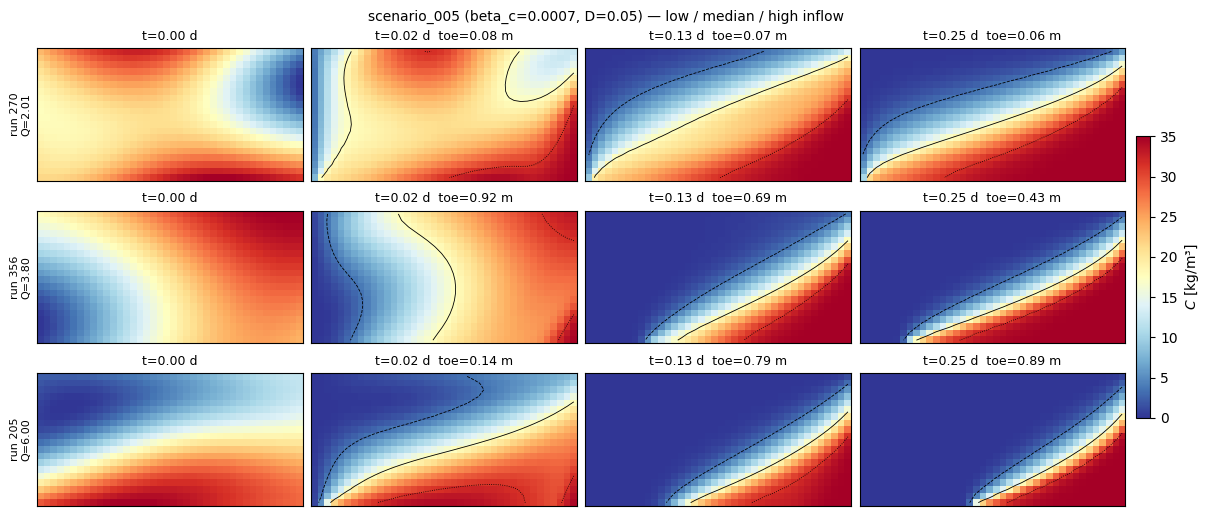

In [9]:
TIME_IDX = [0, 2, T_total // 2, T_total - 1]

order = np.argsort(runs_df['inflow'].values)
pick  = [order[0], order[len(order) // 2], order[-1]]

fig, axes = plt.subplots(len(pick), len(TIME_IDX), figsize=(3.0 * len(TIME_IDX), 1.7 * len(pick)),
                         squeeze=False, constrained_layout=True)
fig.suptitle(f'{SCENARIO} (beta_c={beta_c}, D={diffc}) — low / median / high inflow', fontsize=10)

for r, run_idx in enumerate(pick):
    conc_full, _ = full_timeseries(run_idx)
    for c, tidx in enumerate(TIME_IDX):
        title = f't={times_full[tidx]:.2f} d'
        if tidx > 0:
            title += f'  toe={toe_position(conc_full[tidx]):.2f} m'
        im = _imshow(axes[r, c], conc_full[tidx], title, 'RdYlBu_r', 0, C_SEA,
                     cbar=False, isochlors=tidx > 0, labels=False)
    axes[r, 0].set_ylabel(f'run {run_idx}\nQ={runs_df.inflow[run_idx]:.2f}', fontsize=8)

fig.colorbar(im, ax=axes, shrink=0.6, pad=0.01, label=r'$C$ [kg/m³]')
plt.show()

## 6 · Approach to steady state

For every run in the loaded scenario, coloured by $Q$:
- **left**: toe position over time;
- **right**: largest change between consecutive frames, $\max |C_t - C_{t-1}|$. It falls as the IC is forgotten; a flat tail near zero means the run has reached steady state within the window.

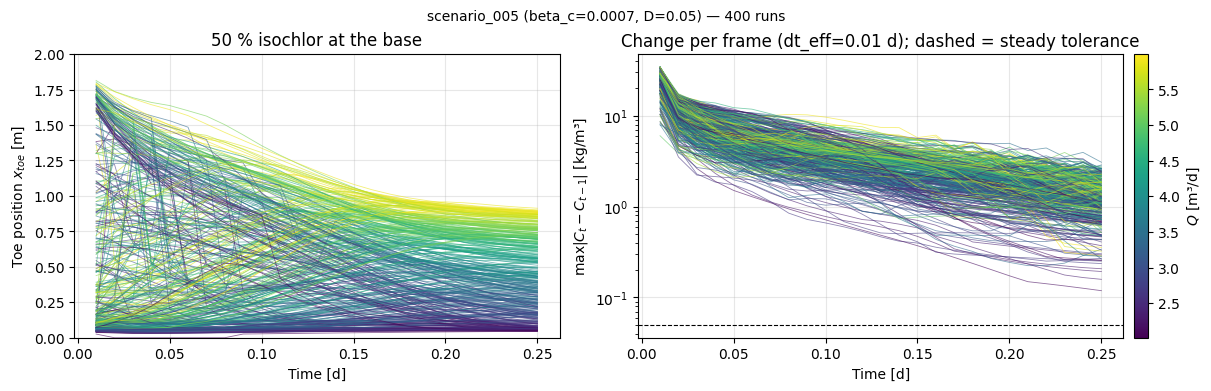

Max change over the last frame: median=1.23  max=3.08 kg/m³
Runs effectively steady at the end (max change < 0.05): 0%


In [10]:
conc_all = np.concatenate([inp[:, CONC_IN, :1], out[:, CONC_OUT]], axis=1)   # (n_runs, T, nlay, ncol)
toe_all  = toe_position(conc_all[:, 1:])                                    # (n_runs, T-1), targets only
step_all = np.abs(np.diff(conc_all, axis=1)).max(axis=(2, 3))              # (n_runs, T-1)
last_change = step_all[:, -1]                                               # (n_runs,)

q = runs_df['inflow'].values
norm = plt.Normalize(q.min(), q.max())
cmap = plt.cm.viridis

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), constrained_layout=True)
fig.suptitle(f'{SCENARIO} (beta_c={beta_c}, D={diffc}) — {n_runs} runs', fontsize=10)
for i in range(n_runs):
    col = cmap(norm(q[i]))
    axes[0].plot(times_full[1:], toe_all[i], color=col, lw=0.6, alpha=0.6)
    axes[1].plot(times_full[1:], np.maximum(step_all[i], 1e-6), color=col, lw=0.6, alpha=0.6)

axes[0].set(xlabel='Time [d]', ylabel=r'Toe position $x_{toe}$ [m]', ylim=(0, lx), title='50 % isochlor at the base')
TOL = 0.05   # kg/m³ per frame (dt_eff)
axes[1].axhline(TOL, color='k', lw=0.8, ls='--')
axes[1].set(xlabel='Time [d]', ylabel=r'$\max |C_t - C_{t-1}|$ [kg/m³]', yscale='log',
            title=f'Change per frame (dt_eff={dt_eff} d); dashed = steady tolerance')
for ax in axes:
    ax.grid(alpha=0.3)
fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=axes, label=r'$Q$ [m³/d]', pad=0.01)
plt.show()

print(f'Max change over the last frame: median={np.median(last_change):.3g}  max={last_change.max():.3g} kg/m³')
print(f'Runs effectively steady at the end (max change < {TOL}): {(last_change < TOL).mean():.0%}')

## 7 · Dataset-wide: final toe position

Final toe position for every run in every scenario.
- **left**: against $Q$, one panel per $\beta_C$, coloured by $D$;
- **right**: against the Henry number $a = Q / (K \varepsilon L_z)$, which should largely collapse the $\beta_C$ dependence.

Only the last output frame is kept in memory per scenario.

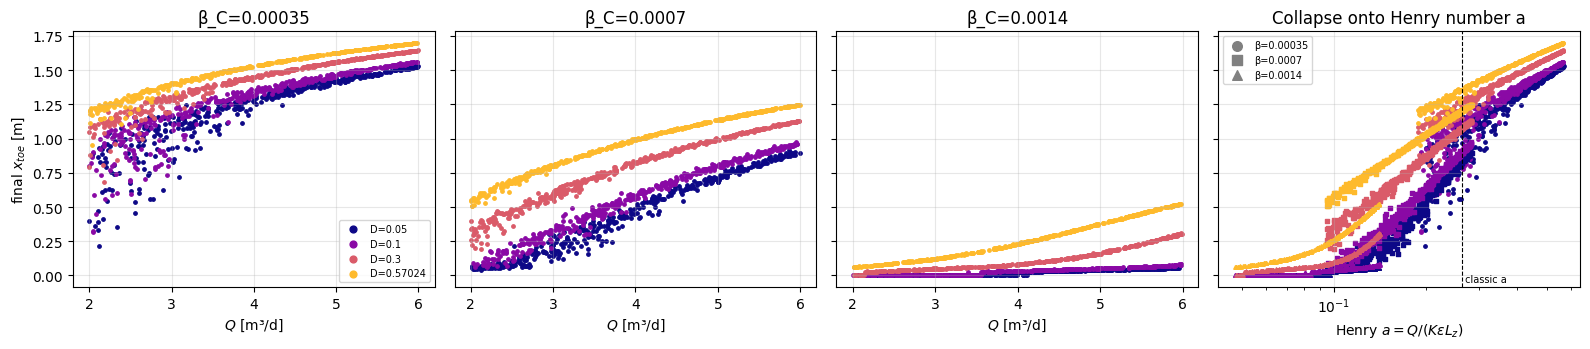

mean       std       min       max
beta_c  diffc                                          
0.00035 0.05000  1.212929  0.264035  0.216521  1.534461
        0.10000  1.268595  0.242638  0.316383  1.559088
        0.30000  1.413938  0.182023  0.683145  1.643468
        0.57024  1.492054  0.153185  0.956287  1.698428
0.00070 0.05000  0.435971  0.277259  0.043337  0.913167
        0.10000  0.561274  0.264903  0.061004  0.971532
        0.30000  0.766095  0.245463  0.197035  1.131631
        0.57024  0.960191  0.203752  0.505028  1.248645
0.00140 0.05000  0.020181  0.020714  0.000000  0.056055
        0.10000  0.031142  0.026602  0.000000  0.084187
        0.30000  0.116271  0.085710  0.000000  0.310061
        0.57024  0.263725  0.141264  0.061314  0.524328

In [11]:
rows = []
for _, s in manifest_df.iterrows():
    d = np.load(DATASET_DIR / s['scenario'] / 'scenario.npz')
    final = d['output_tensor'][:, CONC_OUT, -1]
    toes = toe_position(final)
    for q_i, toe in zip(d['inflow'], toes):
        rows.append({'scenario': s['scenario'], 'beta_c': s['beta_c'], 'diffc': s['diffc'],
                     'inflow': q_i, 'toe': toe,
                     'henry_a': q_i / (HK * s['beta_c'] * C_SEA * lz), 'henry_b': s['diffc'] / q_i})
final_df = pd.DataFrame(rows)

betas  = np.sort(final_df['beta_c'].unique())
diffcs = np.sort(final_df['diffc'].unique())
d_colors = {dc: plt.cm.plasma(i / max(len(diffcs) - 1, 1) * 0.85) for i, dc in enumerate(diffcs)}

fig, axes = plt.subplots(1, len(betas) + 1, figsize=(4.0 * (len(betas) + 1), 3.6), sharey=True)
for ax, b in zip(axes, betas):
    for dc in diffcs:
        sub = final_df[(final_df['beta_c'] == b) & (final_df['diffc'] == dc)]
        ax.scatter(sub['inflow'], sub['toe'], s=6, color=d_colors[dc], label=f'D={dc:g}')
    ax.set(title=f'β_C={b:g}', xlabel=r'$Q$ [m³/d]')
    ax.grid(alpha=0.3)
axes[0].set_ylabel(r'final $x_{toe}$ [m]')
axes[0].legend(fontsize=7, markerscale=2)

ax = axes[-1]
markers = ['o', 's', '^', 'D', 'v']
for i, b in enumerate(betas):
    for dc in diffcs:
        sub = final_df[(final_df['beta_c'] == b) & (final_df['diffc'] == dc)]
        ax.scatter(sub['henry_a'], sub['toe'], s=6, color=d_colors[dc], marker=markers[i % len(markers)])
    ax.scatter([], [], s=12, color='gray', marker=markers[i % len(markers)], label=f'β={b:g}')
ax.axvline(0.263, color='k', lw=0.8, ls='--')
ax.text(0.263, 0.02, ' classic a', fontsize=7, transform=ax.get_xaxis_transform())
ax.set(xscale='log', xlabel=r'Henry $a = Q / (K \varepsilon L_z)$', title='Collapse onto Henry number a')
ax.grid(alpha=0.3)
ax.legend(fontsize=7, markerscale=2)
plt.tight_layout()
plt.show()

final_df.groupby(['beta_c', 'diffc'])['toe'].describe()[['mean', 'std', 'min', 'max']]

## 8 · Target statistics across runs

Mean and standard deviation of concentration and head across all runs of the loaded scenario, at the first target frame and the last.
A high spread at $t_1$ reflects the IC; the spread at the final frame reflects only the range of $Q$.

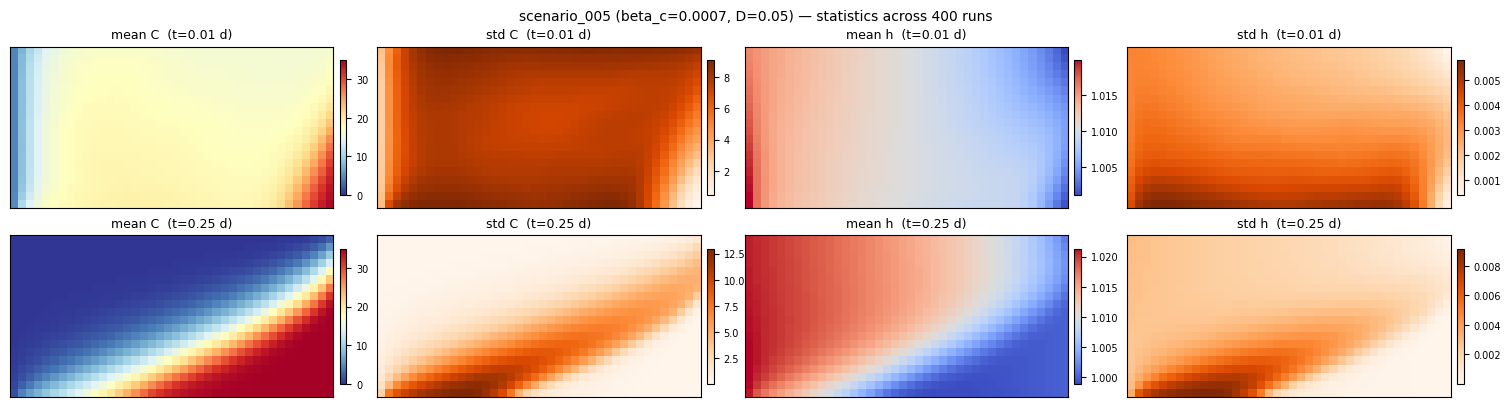

In [12]:
T_IDXS = [0, T_out - 1]   # indices into the output window

fig, axes = plt.subplots(len(T_IDXS), 4, figsize=(15, 2.0 * len(T_IDXS)), squeeze=False, constrained_layout=True)
fig.suptitle(f'{SCENARIO} (beta_c={beta_c}, D={diffc}) — statistics across {n_runs} runs', fontsize=10)

for r, ti in enumerate(T_IDXS):
    c = out[:, CONC_OUT, ti]
    h = out[:, HEAD_OUT, ti]
    t = data['times_out'][ti]
    _imshow(axes[r, 0], c.mean(0), f'mean C  (t={t:.2f} d)', 'RdYlBu_r', 0, C_SEA, labels=False)
    _imshow(axes[r, 1], c.std(0),  f'std C  (t={t:.2f} d)',  'Oranges', labels=False)
    _imshow(axes[r, 2], h.mean(0), f'mean h  (t={t:.2f} d)', 'coolwarm', labels=False)
    _imshow(axes[r, 3], h.std(0),  f'std h  (t={t:.2f} d)',  'Oranges', labels=False)

plt.show()